# Fruits-360 × DINOv3 — Lecture Notebook

A self-contained walkthrough of three complementary ways to explore DINOv3
([ViT-B/16](https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m))
representations on the [Fruits-360](https://www.kaggle.com/datasets/moltean/fruits) dataset.

| Part | Topic | Core idea |
|------|-------|-----------|
| **1 — PCA** | Feature space analysis | Visualise what DINOv3 'sees' with CLS & patch tokens |
| **2 — Similarity** | Cosine similarity | Within-class vs cross-class similarity, dense patch maps |
| **3 — Triplet** | Metric learning | Train a lightweight head to reshape the embedding space |

> **Utility functions** live in `dinov3_utils.py` (same directory).
> This notebook focuses on the conceptual/visualisation code.


## 0 · Setup


In [ ]:
from huggingface_hub import login
token = "my_private_token_which_I_won't_share!!!!!!"
login(token=token, add_to_git_credential=False)

In [11]:
import random, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from collections import defaultdict

import sys; sys.path.insert(0, '.')
import dinov3_utils as du
from dinov3_utils import (
    PATCH_SIZE, IMG_SIZE, N_SIDE, N_PATCH,
    resolve_class, get_paths,
    load_backbone, load_or_compute_features, load_or_compute_cls_embeddings,
    embed_images, extract_patch_tokens,
    pca_rgb_map, patch_sim_map, top_pairs, show_pair_grid,
    TripletNet, IdentityNet, TripletDataset,
    transform, build_centroids, evaluate, separation_score, centroid_predictions,
)

random.seed(42)
np.random.seed(42)

## 0b · Load DINOv3 backbone


In [12]:
MODEL_ID = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
processor, model, DEVICE, NUM_REG = load_backbone(MODEL_ID)

/home/azureuser/cvi4ic-notebooks/11/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading facebook/dinov3-vitb16-pretrain-lvd1689m on cpu …


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 4988.04it/s]

Backbone ready  │  register tokens: 4  │  patch grid: 14×14


In [13]:
# ──────────────────────────────────────────────────────────────────────
# PART 1 — PCA Feature Space Analysis
# Five complementary views of DINOv3 representations via PCA
# ──────────────────────────────────────────────────────────────────────

## 1 · Configuration

| Section | What is visualised | Token type |
|---|---|---|
| A | Global embedding space — class clusters | CLS token (1 per image) |
| B | Semantic parts — per-image breakdown | Patch tokens (196 per image) |
| C | Cross-instance consistency — within one class | Patch tokens (joint fit) |
| D | Cross-class structure — foreground mask + RGB map | Patch tokens (joint fit, all classes) |
| E | PC discriminability — which PCs carry class identity | CLS token |

**Key insight:** PCA fitted *jointly* across multiple images aligns components so that the
same colour in two different images corresponds to the same semantic concept — with no labels.


Classes: ['Pineapple 1', 'Grape Blue 1', 'Lemon 1', 'Strawberry 1', 'Kiwi 1']


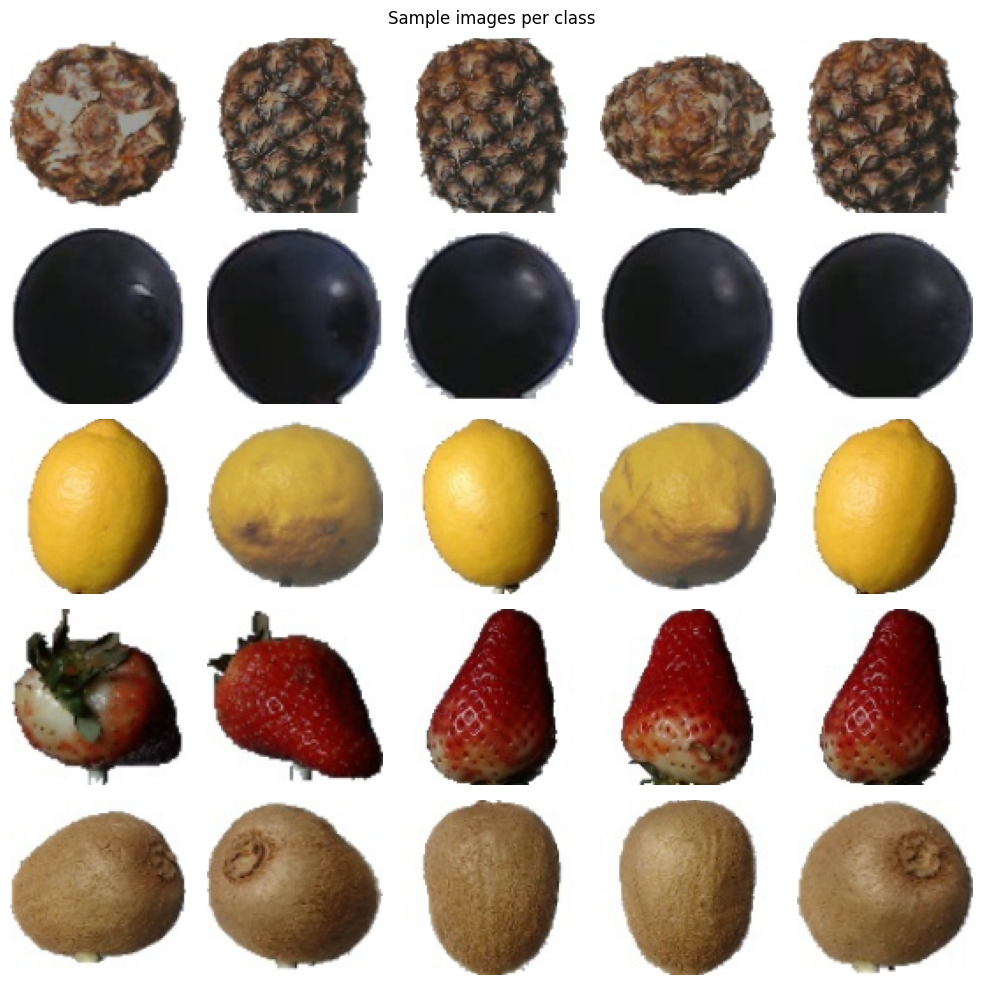

In [20]:
DATASET_PATH = pathlib.Path(r'fruits-360-100x100')   # <-- edit this

TARGET_CLASSES     = ['Pineapple', 'Grape Blue', 'Lemon', 'Strawberry', 'Kiwi']
N_IMAGES_PER_CLASS = 30
PCA_CACHE_DIR      = pathlib.Path('pca_cache')

TRAIN_ROOT = DATASET_PATH / 'Training'
assert TRAIN_ROOT.exists(), f'Training/ not found under {DATASET_PATH}'

available = sorted([d.name for d in TRAIN_ROOT.iterdir() if d.is_dir()])
CLASSES   = [resolve_class(c, available) for c in TARGET_CLASSES]
PALETTE   = sns.color_palette('tab10', n_colors=len(CLASSES))
CLASS_COLOR = {c: PALETTE[i] for i, c in enumerate(CLASSES)}
print('Classes:', CLASSES)

all_paths = {c: get_paths(c, N_IMAGES_PER_CLASS, TRAIN_ROOT) for c in CLASSES}

# Preview grid
P = 5
fig, axes = plt.subplots(len(CLASSES), P, figsize=(P * 2, len(CLASSES) * 2))
for row, cls in enumerate(CLASSES):
    for col, p in enumerate(all_paths[cls][:P]):
        axes[row, col].imshow(Image.open(p)); axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cls.split()[0], fontsize=9, rotation=30, labelpad=40, ha='right')
plt.suptitle('Sample images per class', fontsize=12)
plt.tight_layout(); plt.show()

## 1 · Extract and cache CLS + patch tokens


In [ ]:
cls_tokens, patch_tokens, labels = load_or_compute_features(
    PCA_CACHE_DIR, all_paths, processor, model, DEVICE, NUM_REG
)
label_arr = np.array(labels)

Extracting features (runs once) …


---
## Section A — CLS token PCA: global embedding space

Each image is represented by a single 768-dim CLS token. PCA projects these to 2-D / 3-D
to show how well DINOv3 separates fruit classes *before* any fine-tuning.


In [ ]:
cls_norm = cls_tokens / (np.linalg.norm(cls_tokens, axis=1, keepdims=True) + 1e-8)
pca_cls  = PCA(n_components=20, random_state=42)
Z_cls    = pca_cls.fit_transform(cls_norm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cls in CLASSES:
    mask = label_arr == cls
    axes[0].scatter(Z_cls[mask, 0], Z_cls[mask, 1], c=[CLASS_COLOR[cls]],
                    label=cls, s=35, alpha=0.8, edgecolors='none')
    cx, cy = Z_cls[mask, 0].mean(), Z_cls[mask, 1].mean()
    axes[0].text(cx, cy, cls.split()[0], fontsize=7, fontweight='bold', ha='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, lw=0))
    axes[1].scatter(Z_cls[mask, 1], Z_cls[mask, 2], c=[CLASS_COLOR[cls]],
                    label=cls, s=35, alpha=0.8, edgecolors='none')

for ax, xi, yi in [(axes[0], 0, 1), (axes[1], 1, 2)]:
    ax.set_xlabel(f'PC{xi+1} ({pca_cls.explained_variance_ratio_[xi]*100:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({pca_cls.explained_variance_ratio_[yi]*100:.1f}%)')
    ax.legend(fontsize=8, markerscale=1.5, framealpha=0.7); ax.grid(alpha=0.2)
axes[0].set_title('CLS tokens — PC1 vs PC2')
axes[1].set_title('CLS tokens — PC2 vs PC3')
plt.suptitle('Section A — DINOv3 CLS token PCA (global embedding space)', fontsize=12)
plt.tight_layout(); plt.show()

NameError: name 'cls_tokens' is not defined

### Section A — Scree plot: explained variance per PC


In [ ]:
n_show = 20
evr, cum = pca_cls.explained_variance_ratio_[:n_show], np.cumsum(pca_cls.explained_variance_ratio_[:n_show])

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(range(1, n_show+1), evr*100, color='steelblue', alpha=0.8, label='Per-PC variance')
ax2.plot(range(1, n_show+1), cum*100, color='tomato', marker='o',
         markersize=4, linewidth=1.5, label='Cumulative')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Explained variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative (%)', color='tomato')
ax1.set_xticks(range(1, n_show+1))
ax1.set_title('Scree plot — DINOv3 CLS tokens')
lines = ax1.get_legend_handles_labels(); lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0]+lines2[0], lines[1]+lines2[1], fontsize=9)
ax1.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

NameError: name 'pca_cls' is not defined

---
## Section B — Patch token PCA: per-image semantic breakdown

PCA is fitted on the 196 patch tokens of **a single image**. The first three components
are mapped to R, G, B channels to create a semantic colour map.

Because PCA is fitted *per image*, the components are **not aligned** across images
— see Section C for the joint version.


In [ ]:
rep_idx = {cls: np.where(label_arr == cls)[0][0] for cls in CLASSES}

fig, axes = plt.subplots(5, len(CLASSES), figsize=(len(CLASSES) * 2.5, 11))
row_labels = ['Original', 'PC1', 'PC2', 'PC3', 'PC1–3 (RGB)']

for col, cls in enumerate(CLASSES):
    idx  = rep_idx[cls]
    img  = Image.open(all_paths[cls][0]).convert('RGB')
    ptoks = patch_tokens[idx]                      # (196, 768)
    rgb_map, _ = pca_rgb_map(ptoks)

    pca_full = PCA(n_components=3).fit_transform(ptoks.astype(np.float32))
    pc_maps = []
    for k in range(3):
        v = pca_full[:, k]
        pc_maps.append(((v - v.min()) / (v.max() - v.min() + 1e-8)).reshape(N_SIDE, N_SIDE))

    axes[0, col].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
    for row, pm in enumerate(pc_maps, start=1):
        axes[row, col].imshow(pm, cmap='inferno')
    axes[4, col].imshow(rgb_map)
    for row in range(5): axes[row, col].axis('off')
    axes[0, col].set_title(cls.split()[0], fontsize=9, fontweight='bold',
                            color=CLASS_COLOR[cls])

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=9)
plt.suptitle('Section B — Per-image patch PCA (components NOT aligned across images)', fontsize=11)
plt.tight_layout(); plt.show()

NameError: name 'CLASSES' is not defined

---
## Section C — Joint patch PCA: within-class consistency

PCA is fitted on **all patches from all images of one class combined**.
Because the fit is shared, the same colour in every image means the same semantic region
— consistent part colouring emerges *without any part supervision*.


In [ ]:
FOCUS_CLASS = CLASSES[0]   # change to any class in CLASSES
N_SHOW      = 8

mask        = label_arr == FOCUS_CLASS
cls_patches = patch_tokens[mask]                   # (N_cls, 196, 768)
n_cls       = min(N_SHOW, len(cls_patches))

flat      = cls_patches[:n_cls].reshape(-1, 768).astype(np.float32)
feat_joint = PCA(n_components=3, random_state=42).fit_transform(flat)
for k in range(3):
    mn, mx = feat_joint[:, k].min(), feat_joint[:, k].max()
    feat_joint[:, k] = (feat_joint[:, k] - mn) / (mx - mn + 1e-8)
pc1_thresh = feat_joint[:, 0].mean()
rgb_maps   = feat_joint.reshape(n_cls, N_SIDE, N_SIDE, 3)

cls_img_paths = all_paths[FOCUS_CLASS][:n_cls]
fig, axes = plt.subplots(3, n_cls, figsize=(n_cls * 2.2, 7))
for col in range(n_cls):
    img = Image.open(cls_img_paths[col]).convert('RGB')
    axes[0, col].imshow(img.resize((IMG_SIZE, IMG_SIZE))); axes[0, col].axis('off')
    axes[1, col].imshow(rgb_maps[col]); axes[1, col].axis('off')
    fg_mask = feat_joint[col*N_PATCH:(col+1)*N_PATCH, 0] > pc1_thresh
    masked  = rgb_maps[col].copy().reshape(-1, 3); masked[~fg_mask] = 0
    axes[2, col].imshow(masked.reshape(N_SIDE, N_SIDE, 3)); axes[2, col].axis('off')
axes[0,0].set_ylabel('Original', fontsize=9)
axes[1,0].set_ylabel('Joint PCA (RGB)', fontsize=9)
axes[2,0].set_ylabel('PC1 fg-masked', fontsize=9)
plt.suptitle(f"Section C — Joint patch PCA within '{FOCUS_CLASS}'\n"
             "Same colour = same semantic region across all instances", fontsize=11)
plt.tight_layout(); plt.show()

NameError: name 'CLASSES' is not defined

---
## Section D — Joint patch PCA across all classes

PCA is fitted on patches from **all classes combined**.
- **PC1** reliably separates foreground from background across all classes
- **PC2, PC3** encode class-specific colour and texture


In [ ]:
N_PER_CLASS_D = 6

selected_idx = []
for cls in CLASSES:
    selected_idx.extend(np.where(label_arr == cls)[0][:N_PER_CLASS_D])
selected_idx = np.array(selected_idx)

flat_all = patch_tokens[selected_idx].reshape(-1, 768).astype(np.float32)
feat_all = PCA(n_components=3, random_state=42).fit_transform(flat_all)
for k in range(3):
    mn, mx = feat_all[:, k].min(), feat_all[:, k].max()
    feat_all[:, k] = (feat_all[:, k] - mn) / (mx - mn + 1e-8)
pc1_thresh_all = feat_all[:, 0].mean()
n_sel  = len(selected_idx)
rgb_all = feat_all.reshape(n_sel, N_SIDE, N_SIDE, 3)

# Build index→path mapping (paths ordered class-by-class)
global_paths  = [p for cls in CLASSES for p in all_paths[cls]]
global_labels = [cls for cls in CLASSES for _ in all_paths[cls]]

fig, axes = plt.subplots(3, n_sel, figsize=(n_sel * 1.8, 7))
for col, (gi, pca_rgb) in enumerate(zip(selected_idx, rgb_all)):
    img = Image.open(global_paths[gi]).convert('RGB')
    cls = global_labels[gi]
    axes[0, col].imshow(img.resize((IMG_SIZE, IMG_SIZE))); axes[0, col].axis('off')
    if col % N_PER_CLASS_D == N_PER_CLASS_D // 2:
        axes[0, col].set_title(cls.split()[0], fontsize=7, fontweight='bold',
                                color=CLASS_COLOR[cls], pad=2)
    axes[1, col].imshow(pca_rgb); axes[1, col].axis('off')
    fg = feat_all[col*N_PATCH:(col+1)*N_PATCH, 0] > pc1_thresh_all
    masked = pca_rgb.copy().reshape(-1, 3); masked[~fg] = 0
    axes[2, col].imshow(masked.reshape(N_SIDE, N_SIDE, 3)); axes[2, col].axis('off')
axes[0,0].set_ylabel('Original', fontsize=9)
axes[1,0].set_ylabel('Joint PCA (RGB)', fontsize=9)
axes[2,0].set_ylabel('PC1 fg-masked', fontsize=9)
plt.suptitle('Section D — Joint patch PCA across all classes\n'
             'PC1 = foreground/background  ·  PC2–3 = class texture/colour', fontsize=11)
plt.tight_layout(); plt.show()

---
## Section E — PC discriminability: which PCs carry class identity?

For each of the first 20 PCA components of the CLS tokens, compute the
**between-class variance / total variance** ratio. A high ratio means that component
separates classes well; a low ratio captures intra-class variation or noise.


In [ ]:
N_PCS = 20
pca_disc = PCA(n_components=N_PCS, random_state=42)
Z_disc   = pca_disc.fit_transform(cls_norm)
class_int = np.array([CLASSES.index(l) for l in labels])

separability = []
for k in range(N_PCS):
    vals        = Z_disc[:, k]
    total_var   = vals.var()
    class_means = np.array([vals[class_int == i].mean() for i in range(len(CLASSES))])
    separability.append(class_means.var() / (total_var + 1e-8))
sep = np.array(separability)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#2878b5' if s > sep.mean() else '#aec6e8' for s in sep]
axes[0].bar(range(1, N_PCS+1), sep, color=colors)
axes[0].axhline(sep.mean(), color='tomato', linestyle='--', linewidth=1.2,
                label=f'Mean ({sep.mean():.3f})')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Between-class / total variance')
axes[0].set_title('PC discriminability (↑ = more class-separating)')
axes[0].set_xticks(range(1, N_PCS+1)); axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

top2 = np.argsort(sep)[::-1][:2]
for cls in CLASSES:
    mask = label_arr == cls
    axes[1].scatter(Z_disc[mask, top2[0]], Z_disc[mask, top2[1]],
                    c=[CLASS_COLOR[cls]], label=cls, s=35, alpha=0.85, edgecolors='none')
axes[1].set_xlabel(f'PC{top2[0]+1} (sep={sep[top2[0]]:.3f})')
axes[1].set_ylabel(f'PC{top2[1]+1} (sep={sep[top2[1]]:.3f})')
axes[1].set_title('Scatter on the two most discriminative PCs')
axes[1].legend(fontsize=8, markerscale=1.5, framealpha=0.7); axes[1].grid(alpha=0.2)
plt.suptitle('Section E — DINOv3 CLS token PC discriminability', fontsize=12)
plt.tight_layout(); plt.show()

print('Top-5 most discriminative PCs:')
for rank, i in enumerate(np.argsort(sep)[::-1][:5], 1):
    print(f'  #{rank}  PC{i+1:2d}  sep={sep[i]:.4f}  var={pca_disc.explained_variance_ratio_[i]*100:.2f}%')

### Section E — Per-class projection strips (most discriminative PC)


In [ ]:
best_pc = int(np.argmax(sep))
vals    = Z_disc[:, best_pc]

fig, ax = plt.subplots(figsize=(10, 3.5))
for i, cls in enumerate(CLASSES):
    mask   = label_arr == cls
    v      = vals[mask]
    jitter = np.random.uniform(-0.2, 0.2, size=v.shape)
    ax.scatter(v, np.full_like(v, i) + jitter, c=[CLASS_COLOR[cls]], s=18, alpha=0.7, edgecolors='none')
    ax.plot([v.mean(), v.mean()], [i-0.35, i+0.35], color=CLASS_COLOR[cls], linewidth=2.5)
ax.set_yticks(range(len(CLASSES)))
ax.set_yticklabels([c.split()[0] for c in CLASSES], fontsize=10)
ax.set_xlabel(f'PC{best_pc+1} projection value', fontsize=11)
ax.set_title(f'Most discriminative PC (PC{best_pc+1}, sep={sep[best_pc]:.3f})'
             ' — per-class distribution\n(vertical bar = class mean)', fontsize=11)
ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# PART 2 — Cosine Similarity Visualisation
# Within-class vs cross-class similarity at CLS and dense patch level
# ──────────────────────────────────────────────────────────────────────

## 2 · Configuration — choose two classes


In [ ]:
CLASS_A  = 'Pineapple'
CLASS_B  = 'Grape Blue'
N_IMAGES = 10   # images per class to embed (increase for a richer heatmap)

CLASS_A = resolve_class(CLASS_A, available)
CLASS_B = resolve_class(CLASS_B, available)
print(f'Class A: {CLASS_A}')
print(f'Class B: {CLASS_B}')

paths_a = get_paths(CLASS_A, N_IMAGES, TRAIN_ROOT)
paths_b = get_paths(CLASS_B, N_IMAGES, TRAIN_ROOT)
print(f'Images — A: {len(paths_a)}, B: {len(paths_b)}')

# Preview
PREVIEW = 5
fig, axes = plt.subplots(2, PREVIEW, figsize=(PREVIEW * 2.5, 5))
for col, p in enumerate(paths_a[:PREVIEW]):
    axes[0, col].imshow(Image.open(p)); axes[0, col].axis('off')
axes[0, 0].set_ylabel(CLASS_A, fontsize=11)
for col, p in enumerate(paths_b[:PREVIEW]):
    axes[1, col].imshow(Image.open(p)); axes[1, col].axis('off')
axes[1, 0].set_ylabel(CLASS_B, fontsize=11)
plt.suptitle(f'Sample images: {CLASS_A} vs {CLASS_B}', fontsize=13)
plt.tight_layout(); plt.show()

## 2 · Extract CLS embeddings


In [ ]:
print(f'Embedding {CLASS_A} …')
emb_a = embed_images(paths_a, processor, model, DEVICE)
print(f'Embedding {CLASS_B} …')
emb_b = embed_images(paths_b, processor, model, DEVICE)
print(f'Shapes: A={emb_a.shape}, B={emb_b.shape}')

## 2 · Build the cosine similarity matrix

Since embeddings are L2-normalised, cosine similarity = dot product.
We build a **(2N × 2N)** matrix covering all four quadrants:

| | A images | B images |
|---|---|---|
| **A images** | within-class A (high sim expected) | cross-class (low sim expected) |
| **B images** | cross-class (low sim expected) | within-class B (high sim expected) |


In [ ]:
import torch
na, nb = len(emb_a), len(emb_b)
all_emb   = torch.cat([emb_a, emb_b], dim=0)
sim_matrix = (all_emb @ all_emb.T).cpu().numpy()

aa = sim_matrix[:na, :na]
bb = sim_matrix[na:, na:]
ab = sim_matrix[:na, na:]

print(f'Within-{CLASS_A:<15s} avg cosine sim: {aa[~np.eye(na, dtype=bool)].mean():.4f}')
print(f'Within-{CLASS_B:<15s} avg cosine sim: {bb[~np.eye(nb, dtype=bool)].mean():.4f}')
print(f'Cross-class            avg cosine sim: {ab.mean():.4f}')

## 2 · Heatmap — full pairwise similarity matrix


In [ ]:
short_labels = [f'A{i+1}' for i in range(na)] + [f'B{i+1}' for i in range(nb)]

fig, ax = plt.subplots(figsize=(max(8, na+nb), max(7, na+nb-1)))
mask = np.eye(na+nb, dtype=bool)
sns.heatmap(sim_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, ax=ax)
ax.axvline(x=na, color='black', linewidth=2)
ax.axhline(y=na, color='black', linewidth=2)
ax.text(na/2,       -0.8, CLASS_A, ha='center', va='bottom', fontsize=11, fontweight='bold', color='steelblue')
ax.text(na+nb/2,    -0.8, CLASS_B, ha='center', va='bottom', fontsize=11, fontweight='bold', color='tomato')
ax.text(-0.6, na/2, CLASS_A, ha='right', va='center', fontsize=11, fontweight='bold', color='steelblue', rotation=90)
ax.text(-0.6, na+nb/2, CLASS_B, ha='right', va='center', fontsize=11, fontweight='bold', color='tomato', rotation=90)
ax.set_title(
    f'DINOv3 Cosine Similarity — {CLASS_A} vs {CLASS_B}\n'
    f"within-{CLASS_A}: {aa[~np.eye(na,dtype=bool)].mean():.3f}  |  "
    f"within-{CLASS_B}: {bb[~np.eye(nb,dtype=bool)].mean():.3f}  |  "
    f"cross-class: {ab.mean():.3f}", fontsize=12)
plt.tight_layout(); plt.show()

## 2 · High-similarity pairs vs low-similarity pairs


In [ ]:
K = 3
aa_nd = aa.copy(); np.fill_diagonal(aa_nd, -np.inf)
bb_nd = bb.copy(); np.fill_diagonal(bb_nd, -np.inf)

hi_a  = top_pairs(aa_nd,  K, highest=True,  exclude_diagonal=False)
hi_b  = top_pairs(bb_nd,  K, highest=True,  exclude_diagonal=False)
lo_ab = top_pairs(ab,     K, highest=False,  exclude_diagonal=False)

show_pair_grid(hi_a,  paths_a, paths_a, f'High similarity — within {CLASS_A} (similar)',     'steelblue')
show_pair_grid(hi_b,  paths_b, paths_b, f'High similarity — within {CLASS_B} (similar)',     'seagreen')
show_pair_grid(lo_ab, paths_a, paths_b, f'Low similarity — {CLASS_A} vs {CLASS_B} (non-similar)', 'crimson')

## 2 · Distribution plot: within-class vs cross-class similarity


In [ ]:
within_a_vals = aa[~np.eye(na, dtype=bool)]
within_b_vals = bb[~np.eye(nb, dtype=bool)]
cross_vals    = ab.flatten()

bins = np.linspace(min(cross_vals.min(), within_a_vals.min(), within_b_vals.min()) - 0.02, 1.01, 30)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(within_a_vals, bins=bins, alpha=0.65, label=f'Within {CLASS_A}',  color='steelblue', density=True)
ax.hist(within_b_vals, bins=bins, alpha=0.65, label=f'Within {CLASS_B}',  color='seagreen',  density=True)
ax.hist(cross_vals,    bins=bins, alpha=0.65, label='Cross-class (A↔B)', color='crimson',    density=True)
for vals, color in [(within_a_vals,'steelblue'),(within_b_vals,'seagreen'),(cross_vals,'crimson')]:
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('Cosine similarity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'DINOv3 embedding similarity distributions\n{CLASS_A} vs {CLASS_B}  (dashed = mean)', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'\nSummary:')
print(f'  within-{CLASS_A:<15s}: mean={within_a_vals.mean():.4f}  std={within_a_vals.std():.4f}')
print(f'  within-{CLASS_B:<15s}: mean={within_b_vals.mean():.4f}  std={within_b_vals.std():.4f}')
print(f'  cross-class        : mean={cross_vals.mean():.4f}  std={cross_vals.std():.4f}')

## 2 · Bonus — Sorted similarity strip: most → least similar


In [ ]:
QUERY_IDX   = 0
query_emb   = emb_a[QUERY_IDX].unsqueeze(0)
gallery_emb = torch.cat([emb_a, emb_b])
sims_all    = (query_emb @ gallery_emb.T).squeeze(0).cpu().numpy()
all_paths_list  = list(paths_a) + list(paths_b)
all_labels_list = [CLASS_A]*na + [CLASS_B]*nb
ranked = [i for i in np.argsort(-sims_all) if i != QUERY_IDX]

SHOW = min(10, len(ranked))
fig, axes = plt.subplots(2, SHOW+1, figsize=((SHOW+1)*2, 5))
for row_idx, ranked_slice in enumerate([ranked[:SHOW], ranked[-SHOW:]]):
    for col, idx in enumerate(ranked_slice):
        ax = axes[row_idx, col+1]
        ax.imshow(Image.open(all_paths_list[idx])); ax.axis('off')
        color = 'steelblue' if all_labels_list[idx] == CLASS_A else 'tomato'
        ax.set_title(f'{sims_all[idx]:.3f}\n{all_labels_list[idx].split()[0]}', fontsize=7, color=color)
    axes[row_idx, 0].imshow(Image.open(paths_a[QUERY_IDX]))
    axes[row_idx, 0].axis('off')
axes[0, 0].set_title('QUERY', fontsize=8, fontweight='bold')
plt.suptitle(f'DINOv3 similarity ranking — query: {CLASS_A}\n'
             'Blue = same class (similarity)  ·  Red = different class (non-similarity)', fontsize=11)
plt.tight_layout(); plt.show()

## 2 · Dense patch-level similarity map

For a selected patch in the query image, compute cosine similarity to **every patch**
in same-class and cross-class target images.
Bright = high similarity, dark = low similarity.


In [ ]:
import torch.nn.functional as F
import matplotlib.patches as mpatches

QUERY_PATH    = paths_a[0]
QUERY_PATCHES = [(3, 7), (7, 7), (10, 7)]         # (row, col) in 14×14 grid
PATCH_COLORS  = ['#e74c3c', '#2ecc71', '#3498db']  # red, green, blue
N_TARGETS     = 4

query_tok    = extract_patch_tokens(QUERY_PATH, processor, model, DEVICE, NUM_REG)
same_paths   = [p for p in paths_a if p != QUERY_PATH][:N_TARGETS]
cross_paths  = paths_b[:N_TARGETS]
same_tokens  = [extract_patch_tokens(p, processor, model, DEVICE, NUM_REG) for p in same_paths]
cross_tokens = [extract_patch_tokens(p, processor, model, DEVICE, NUM_REG) for p in cross_paths]

In [ ]:
N_ROWS  = len(QUERY_PATCHES)
fig = plt.figure(figsize=(2.4 * (1 + N_TARGETS*2 + 0.5), 2.6*N_ROWS + 0.8))
gs  = gridspec.GridSpec(
    N_ROWS, 1 + N_TARGETS + 1 + N_TARGETS, figure=fig,
    wspace=0.04, hspace=0.12,
    width_ratios=[1] + [1]*N_TARGETS + [0.08] + [1]*N_TARGETS,
)
query_arr = np.array(Image.open(QUERY_PATH).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))

for row_idx, (qrc, color) in enumerate(zip(QUERY_PATCHES, PATCH_COLORS)):
    r, c = qrc
    ax_q = fig.add_subplot(gs[row_idx, 0])
    ax_q.imshow(query_arr)
    ax_q.add_patch(mpatches.FancyBboxPatch(
        (c*PATCH_SIZE, r*PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
        boxstyle='square,pad=0', linewidth=2.5,
        edgecolor=color, facecolor=color, alpha=0.45))
    ax_q.axis('off')
    if row_idx == 0: ax_q.set_title('Query', fontsize=8, fontweight='bold', pad=3)

    for t_idx, (t_path, t_tok) in enumerate(zip(same_paths, same_tokens)):
        ax   = fig.add_subplot(gs[row_idx, 1+t_idx])
        t_img = np.array(Image.open(t_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        smap  = patch_sim_map(query_tok, qrc, t_tok)
        ax.imshow(t_img, alpha=0.45)
        ax.imshow(np.kron(smap, np.ones((PATCH_SIZE, PATCH_SIZE))),
                  cmap='inferno', alpha=0.75, vmin=smap.min(), vmax=smap.max())
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(f'Same\n({CLASS_A.split()[0]})', fontsize=7, pad=3,
                         color='steelblue', fontweight='bold')

    fig.add_subplot(gs[row_idx, 1+N_TARGETS]).axis('off')   # spacer

    for t_idx, (t_path, t_tok) in enumerate(zip(cross_paths, cross_tokens)):
        ax   = fig.add_subplot(gs[row_idx, 2+N_TARGETS+t_idx])
        t_img = np.array(Image.open(t_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        smap  = patch_sim_map(query_tok, qrc, t_tok)
        ax.imshow(t_img, alpha=0.45)
        ax.imshow(np.kron(smap, np.ones((PATCH_SIZE, PATCH_SIZE))),
                  cmap='inferno', alpha=0.75, vmin=smap.min(), vmax=smap.max())
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(f'Cross\n({CLASS_B.split()[0]})', fontsize=7, pad=3,
                         color='tomato', fontweight='bold')

fig.suptitle(
    f'DINOv3 dense patch cosine similarity — query: {CLASS_A}\n'
    'Each row = one query patch  ·  bright = high similarity  ·  dark = low similarity',
    fontsize=10, y=1.01)
plt.savefig('patch_similarity_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → patch_similarity_map.png')

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# PART 3 — Triplet Loss Metric Learning
# Train a lightweight MLP head to reshape the DINOv3 embedding space
# ──────────────────────────────────────────────────────────────────────

## 3 · Configuration

Triplet Loss:  **L = max(0, d(a,p) − d(a,n) + margin)**

The classes below are intentionally **hard** — DINOv3 raw features barely separate them,
so the triplet head has real work to do.

Uncomment one of the preset groups or define your own.


In [ ]:
# ── Classes (pick one group or define your own) ────────────────────────
# Citrus — 4 round orange fruits; differ only in size/shade
TARGET_CLASSES_TRIPLET = ['Orange 1', 'Orange 2', 'Orange 3', 'Mandarine 1', 'Clementine 1']

# Apple varieties — same fruit, different colour
# TARGET_CLASSES_TRIPLET = ['Apple Red 1', 'Apple Red 2', 'Apple Red 3',
#                            'Apple Golden 1', 'Apple Granny Smith']

# Cherry varieties — small round stone fruits
# TARGET_CLASSES_TRIPLET = ['Cherry 1', 'Cherry 2', 'Cherry Rainier',
#                            'Cherry Wax Red', 'Cherry Wax Yellow']

N_IMAGES_TRIPLET = 60
TEST_FRACTION    = 0.2

# ── Training hyper-parameters ───────────────────────────────────────
EMBEDDING_DIM = 256
EPOCHS        = 60
BATCH_SIZE    = 128
LR            = 1e-3
MARGIN        = 0.3

TRIPLET_CACHE_DIR = pathlib.Path('triplet_cache')
TRIPLET_MODEL_PATH = TRIPLET_CACHE_DIR / 'triplet_head.pth'

# ── Resolve class names and preview ─────────────────────────────────
CLASSES_T = [resolve_class(c, available) for c in TARGET_CLASSES_TRIPLET]
print('Resolved classes:', CLASSES_T)

all_paths_t = {c: get_paths(c, N_IMAGES_TRIPLET, TRAIN_ROOT) for c in CLASSES_T}
print('\nImages per class:')
for c, ps in all_paths_t.items(): print(f'  {c}: {len(ps)}')

PREVIEW = 5
fig, axes = plt.subplots(len(CLASSES_T), PREVIEW, figsize=(PREVIEW*2, len(CLASSES_T)*2))
for row, (cls, paths_t) in enumerate(all_paths_t.items()):
    for col, p in enumerate(paths_t[:PREVIEW]):
        axes[row, col].imshow(Image.open(p)); axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cls, fontsize=8, rotation=30, labelpad=40, ha='right')
plt.suptitle('Sample images per class (triplet training)', fontsize=12)
plt.tight_layout(); plt.show()

## 3 · Pre-compute and cache DINOv3 embeddings


In [ ]:
embeddings, labels_t = load_or_compute_cls_embeddings(
    TRIPLET_CACHE_DIR, all_paths_t, processor, model, DEVICE
)

## 3 · Train / test split


In [ ]:
by_class_all = defaultdict(list)
for i, lbl in enumerate(labels_t): by_class_all[lbl].append(i)

train_idx, test_idx_t = [], []
for cls, idxs in by_class_all.items():
    random.shuffle(idxs)
    n_test = max(1, int(len(idxs) * TEST_FRACTION))
    test_idx_t.extend(idxs[:n_test]); train_idx.extend(idxs[n_test:])

train_emb    = embeddings[train_idx]; train_labels_t = [labels_t[i] for i in train_idx]
test_emb     = embeddings[test_idx_t]; test_labels_t  = [labels_t[i] for i in test_idx_t]

train_by_class = defaultdict(list)
for emb, lbl in zip(train_emb, train_labels_t): train_by_class[lbl].append(emb)
train_by_class = {k: np.array(v) for k, v in train_by_class.items()}

print('Split summary:')
for cls in CLASSES_T:
    n_tr = sum(1 for l in train_labels_t if l == cls)
    n_te = sum(1 for l in test_labels_t  if l == cls)
    print(f'  {cls}: {n_tr} train / {n_te} test')

## 3 · Train the metric head

```
TripletNet:  768 → Linear(512) → ReLU → Dropout(0.2)
                 → Linear(512) → ReLU → Dropout(0.2)
                 → Linear(256) → L2-normalise
```

The backbone is **never updated** — training runs on pre-computed features,
so it completes in seconds even on CPU.


In [ ]:
head      = TripletNet(embedding_dim=EMBEDDING_DIM)
optimizer = torch.optim.Adam(head.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

dataset = TripletDataset(train_by_class)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

loss_history = []
head.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for anchor, positive, negative in loader:
        optimizer.zero_grad()
        loss = criterion(head(anchor), head(positive), head(negative))
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg = epoch_loss / len(loader)
    loss_history.append(avg)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={avg:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')

TRIPLET_CACHE_DIR.mkdir(exist_ok=True)
torch.save(head.state_dict(), TRIPLET_MODEL_PATH)
print(f'\nModel saved → {TRIPLET_MODEL_PATH}')

## 3 · Training loss curve


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, EPOCHS+1), loss_history, linewidth=2, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Triplet loss')
ax.set_title('Training loss — TripletNet head on DINOv3 features')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3 · Evaluation — 1-NN accuracy & centroid accuracy

**Baseline** (`IdentityNet`): fixed random orthogonal projection 768→256 (no learned structure).

**Trained** (`TripletNet`): the head trained above.


In [ ]:
baseline_net      = IdentityNet(embedding_dim=EMBEDDING_DIM)
centroids_raw     = build_centroids(baseline_net, train_by_class)
centroids_trained = build_centroids(head,         train_by_class)

print('--- Test-set evaluation ---')
before = evaluate(baseline_net, test_emb, test_labels_t, CLASSES_T, centroids_raw)
after  = evaluate(head,         test_emb, test_labels_t, CLASSES_T, centroids_trained)

print(f"{'Metric':<22} {'Before (raw)':>14} {'After (trained)':>16}")
print('-' * 54)
for k in before:
    print(f'{k:<22} {before[k]:>13.1%} {after[k]:>15.1%}')

## 3 · Separation score: inter / intra distance ratio


In [ ]:
sep_before = separation_score(baseline_net, train_by_class)
sep_after  = separation_score(head,         train_by_class)

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Raw DINOv3\n(random proj)', 'Trained\nTripletNet'],
              [sep_before, sep_after], color=['#aec6e8', '#2878b5'], width=0.4)
ax.bar_label(bars, fmt='%.2f', fontsize=11, padding=4)
ax.set_ylabel('Separation score (↑ better)')
ax.set_title('Inter / intra-class distance ratio')
ax.set_ylim(0, max(sep_before, sep_after) * 1.25)
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
print(f'Before: {sep_before:.2f}   After: {sep_after:.2f}')

## 3 · t-SNE — embedding space before vs after training

Joint t-SNE on all embeddings (train + test) — raw DINOv3 vs TripletNet output.


In [ ]:
PALETTE_T  = sns.color_palette('tab10', n_colors=len(CLASSES_T))
COLOR_MAP_T = {cls: PALETTE_T[i] for i, cls in enumerate(CLASSES_T)}

all_emb_raw     = transform(baseline_net, embeddings)
all_emb_trained = transform(head,         embeddings)

print('Running t-SNE on raw features…')
Z_raw     = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(all_emb_raw)
print('Running t-SNE on trained features…')
Z_trained = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(all_emb_trained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, title in [
    (axes[0], Z_raw,     'Raw DINOv3 (random projection)'),
    (axes[1], Z_trained, 'After TripletNet training'),
]:
    for cls in CLASSES_T:
        mask = [l == cls for l in labels_t]
        ax.scatter(Z[mask, 0], Z[mask, 1], c=[COLOR_MAP_T[cls]], label=cls,
                   s=18, alpha=0.75, edgecolors='none')
    ax.set_title(title, fontsize=11); ax.axis('off')
handles = [plt.scatter([], [], c=[COLOR_MAP_T[c]], s=40, label=c) for c in CLASSES_T]
fig.legend(handles=handles, loc='lower center', ncol=len(CLASSES_T),
           bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
plt.suptitle('t-SNE — DINOv3 feature space before vs after Triplet Loss training', fontsize=12)
plt.tight_layout(); plt.show()

## 3 · Per-class accuracy breakdown + confusion matrix


In [ ]:
preds_before = centroid_predictions(baseline_net, test_emb, centroids_raw)
preds_after  = centroid_predictions(head,         test_emb, centroids_trained)

print(f"{'Class':<22}  {'Before':>7}  {'After':>7}")
print('-' * 42)
for cls in CLASSES_T:
    mask  = [l == cls for l in test_labels_t]
    t     = np.array(test_labels_t)[mask]
    acc_b = (np.array(preds_before)[mask] == t).mean()
    acc_a = (np.array(preds_after)[mask]  == t).mean()
    delta = acc_a - acc_b
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'{cls:<22}  {acc_b:>6.1%}  {acc_a:>6.1%}  {arrow}{abs(delta):.1%}')

cm = confusion_matrix(test_labels_t, preds_after, labels=CLASSES_T)
fig, ax = plt.subplots(figsize=(len(CLASSES_T)*1.2+1, len(CLASSES_T)*1.1+1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.split()[0] for c in CLASSES_T],
            yticklabels=[c.split()[0] for c in CLASSES_T], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix — centroid classifier (after training)')
plt.tight_layout(); plt.show()

## 3 · Qualitative: correct and incorrect test predictions


In [ ]:
# Rebuild test image paths in the same order as test_emb
test_paths_t = []
for idx in test_idx_t:
    cls = labels_t[idx]
    cls_idxs    = [i for i, l in enumerate(labels_t) if l == cls]
    pos_in_class = cls_idxs.index(idx)
    test_paths_t.append(all_paths_t[cls][pos_in_class])

correct_mask   = [p == g for p, g in zip(preds_after, test_labels_t)]
incorrect_mask = [not m for m in correct_mask]

def show_predictions(mask, title, max_show=8):
    idxs = [i for i, m in enumerate(mask) if m][:max_show]
    if not idxs: print(f'No examples for: {title}'); return
    fig, axes = plt.subplots(1, len(idxs), figsize=(len(idxs)*2, 2.8))
    if len(idxs) == 1: axes = [axes]
    for ax, i in zip(axes, idxs):
        ax.imshow(Image.open(test_paths_t[i])); ax.axis('off')
        color = 'green' if correct_mask[i] else 'red'
        ax.set_title(f"T: {test_labels_t[i].split()[0]}\nP: {preds_after[i].split()[0]}",
                     fontsize=7, color=color)
    plt.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

show_predictions(correct_mask,   'Correct predictions (green)')
show_predictions(incorrect_mask, 'Incorrect predictions (red)')